In [ ]:

import pandas as pd

train_df = pd.read_csv("/content/train.csv")
val_df = pd.read_csv("/content/test.csv")
test_df = pd.read_csv("/content/val.csv")

In [ ]:
train_df.head()

,tweet_id,user_handle,timestamp,tweet_text,candidate,party,retweets,likes,sentiment
0,1,@user123,2024-11-03 08:45:00,Excited to see Kamala Harris leading the Democ...,Kamala Harris,Democratic Party,120,450,positive
1,2,@politicsFan,2024-11-03 09:15:23,Donald Trump's policies are the best for our e...,Donald Trump,Republican Party,85,300,positive
2,3,@greenAdvocate,2024-11-03 10:05:45,Jill Stein's environmental plans are exactly w...,Jill Stein,Green Party,60,200,positive
3,4,@indieVoice,2024-11-03 11:20:10,Robert Kennedy offers a fresh perspective outs...,Robert Kennedy,Independent,40,150,neutral
4,5,@libertyLover,2024-11-03 12:35:55,Chase Oliver's libertarian stance promotes tru...,Chase Oliver,Libertarian Party,30,120,positive


In [ ]:
test_df.head()

,tweet_id,user_handle,timestamp,tweet_text,candidate,party,retweets,likes,sentiment
0,551,@user1077,2025-02-21 08:30:10,Kamala Harris's new policy on education reform...,Kamala Harris,Democratic Party,85,320,positive
1,552,@politicsNew3,2025-02-21 09:15:20,Donald Trump's latest speech on the economy wa...,Donald Trump,Republican Party,100,450,positive
2,553,@greenVisionary3,2025-02-21 10:05:35,Jill Stein's environmental policies are a step...,Jill Stein,Green Party,60,200,positive
3,554,@indieWatcher3,2025-02-21 11:25:40,Robert Kennedy's independent run brings fresh ...,Robert Kennedy,Independent,30,120,neutral
4,555,@libertyFan5,2025-02-21 12:40:50,Chase Oliver's stance on gun rights is unwaver...,Chase Oliver,Libertarian Party,50,160,positive


In [ ]:
val_df.head()

,tweet_id,user_handle,timestamp,tweet_text,candidate,party,retweets,likes,sentiment
0,501,@user1068,2025-02-11 08:30:10,Kamala Harris's new policy on education reform...,Kamala Harris,Democratic Party,85,320,positive
1,502,@politicsNew2,2025-02-11 09:15:20,Donald Trump's latest speech on the economy wa...,Donald Trump,Republican Party,100,450,positive
2,503,@greenVisionary2,2025-02-11 10:05:35,Jill Stein's environmental policies are a step...,Jill Stein,Green Party,60,200,positive
3,504,@indieWatcher2,2025-02-11 11:25:40,Robert Kennedy's independent run brings fresh ...,Robert Kennedy,Independent,30,120,neutral
4,505,@libertyFan4,2025-02-11 12:40:50,Chase Oliver's stance on gun rights is unwaver...,Chase Oliver,Libertarian Party,50,160,positive


In [ ]:
cols_to_drop = ['tweet_id', 'user_handle', 'timestamp']

train_df = train_df.drop(columns=cols_to_drop, errors='ignore')
val_df = val_df.drop(columns=cols_to_drop, errors='ignore')
test_df = test_df.drop(columns=cols_to_drop, errors='ignore')


In [ ]:
train_df.head()

,tweet_text,candidate,party,retweets,likes,sentiment
0,Excited to see Kamala Harris leading the Democ...,Kamala Harris,Democratic Party,120,450,positive
1,Donald Trump's policies are the best for our e...,Donald Trump,Republican Party,85,300,positive
2,Jill Stein's environmental plans are exactly w...,Jill Stein,Green Party,60,200,positive
3,Robert Kennedy offers a fresh perspective outs...,Robert Kennedy,Independent,40,150,neutral
4,Chase Oliver's libertarian stance promotes tru...,Chase Oliver,Libertarian Party,30,120,positive


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   tweet_text  500 non-null    object
 1   candidate   500 non-null    object
 2   party       500 non-null    object
 3   retweets    500 non-null    int64 
 4   likes       500 non-null    int64 
 5   sentiment   500 non-null    object
dtypes: int64(2), object(4)
memory usage: 23.6+ KB


In [ ]:
# Preprocess (convert sentiment to score, compute engagement)

def preprocess(df):
    sentiment_map = {'positive': 1.0, 'neutral': 0.0, 'negative': -1.0}

    df['engagement'] = df['retweets'] + df['likes']
    df['sentiment_score'] = df['sentiment'].map(sentiment_map)

    df = df.drop(columns=['retweets', 'likes'])

    return df.dropna(subset=['tweet_text', 'sentiment_score'])

train_df = preprocess(train_df)
val_df = preprocess(val_df)
test_df = preprocess(test_df)

In [ ]:
train_df.head()

,tweet_text,candidate,party,sentiment,engagement,sentiment_score
0,Excited to see Kamala Harris leading the Democ...,Kamala Harris,Democratic Party,positive,570,1.0
1,Donald Trump's policies are the best for our e...,Donald Trump,Republican Party,positive,385,1.0
2,Jill Stein's environmental plans are exactly w...,Jill Stein,Green Party,positive,260,1.0
3,Robert Kennedy offers a fresh perspective outs...,Robert Kennedy,Independent,neutral,190,0.0
4,Chase Oliver's libertarian stance promotes tru...,Chase Oliver,Libertarian Party,positive,150,1.0


In [ ]:
# Set up TextVectorization

from tensorflow.keras.layers import TextVectorization

max_tokens = 20000
max_len = 50

vectorizer = TextVectorization(max_tokens=max_tokens, output_mode='int', output_sequence_length=max_len)
vectorizer.adapt(train_df['tweet_text'].values)

In [ ]:
vocab = vectorizer.get_vocabulary()
print(vocab[:20])  # print first 20 tokens


['', '[UNK]', np.str_('is'), np.str_('are'), np.str_('to'), np.str_('trumps'), np.str_('robert'), np.str_('kamala'), np.str_('jill'), np.str_('chase'), np.str_('for'), np.str_('the'), np.str_('policies'), np.str_('a'), np.str_('kennedy'), np.str_('steins'), np.str_('harris'), np.str_('oliver'), np.str_('on'), np.str_('new')]


In [ ]:
# --- STEP 7: Build CNN model using Functional API ---
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D, Dense, Concatenate
from tensorflow.keras.models import Model

embedding_dim = 64

# Inputs
text_input = Input(shape=(1,), dtype=tf.string, name='tweet_text')
# sentiment_score_input = Input(shape=(1,), dtype='float32', name='sentiment_score')
engagement_input = Input(shape=(1,), dtype='float32', name='engagement')

# Text preprocessing and embedding
x_text = vectorizer(text_input)
x_text = Embedding(input_dim=max_tokens, output_dim=embedding_dim)(x_text)
x_text = Conv1D(128, 5, activation='relu')(x_text)
x_text = GlobalMaxPooling1D()(x_text)

# Combine with numeric features
x = Concatenate()([x_text, engagement_input])
# x = Concatenate()([x_text, sentiment_score_input, engagement_input])

x = Dense(64, activation='relu')(x)
x = Dense(32, activation='relu')(x)

output = Dense(1, activation='linear', name='predicted_sentiment')(x)

model = Model(inputs=[text_input, engagement_input], outputs=output)

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tweet_text          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization… │ (None, 50)        │          0 │ tweet_text[0][0]  │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 50, 64)    │  1,280,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 46, 128)   │     41,088 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ engagement          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 129)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ engagement[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      8,320 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 32)        │      2,080 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ predicted_sentiment │ (None, 1)         │         33 │ dense_5[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,331,521 (5.08 MB)

 Trainable params: 1,331,521 (5.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# --- Prepare training and validation inputs ---
train_texts = train_df['tweet_text'].values
# train_sentiment_scores = train_df['sentiment_score'].values.astype('float32')
train_engagement = train_df['engagement'].values.astype('float32')
train_targets = train_df['sentiment_score'].values.astype('float32')  # target here could be sentiment or another label

val_texts = val_df['tweet_text'].values
# val_sentiment_scores = val_df['sentiment_score'].values.astype('float32')
val_engagement = val_df['engagement'].values.astype('float32')
val_targets = val_df['sentiment_score'].values.astype('float32')

In [ ]:
# --- Train the model ---
history = model.fit(
    {'tweet_text': train_texts,
    #  'sentiment_score': train_sentiment_scores,
     'engagement': train_engagement},
    train_targets,
    validation_data=(
        {'tweet_text': val_texts,
        #  'sentiment_score': val_sentiment_scores,
         'engagement': val_engagement},
        val_targets),
    epochs=70,
    batch_size=32
)

Epoch 1/70
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 141.9502 - mae: 9.2977 - val_loss: 16.0487 - val_mae: 3.4980
Epoch 2/70
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 7.4181 - mae: 2.1304 - val_loss: 2.2402 - val_mae: 1.3285
Epoch 3/70
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 1.5798 - mae: 0.9622 - val_loss: 0.3890 - val_mae: 0.5396
Epoch 4/70
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.5724 - mae: 0.6540 - val_loss: 0.3812 - val_mae: 0.4476
Epoch 5/70
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.4378 - mae: 0.4941 - val_loss: 0.3778 - val_mae: 0.5508
Epoch 6/70
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.4223 - mae: 0.5468 - val_loss: 0.3349 - val_mae: 0.5126
Epoch 7/70
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.3565 - mae: 0.5099 - val_loss: 0.2900 - val_mae: 0.4693
Epoch 8/70
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.3067 - mae: 0.4768 - val_loss: 0.2336 - val_mae: 0.4060
Epoch 9/70
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.

In [ ]:
# --- Predict sentiment on test set ---
test_texts = test_df['tweet_text'].values
test_engagement = test_df['engagement'].values.astype('float32')

test_preds = model.predict({'tweet_text': test_texts, 'engagement': test_engagement})
test_df['predicted_sentiment'] = test_preds.flatten()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step


In [ ]:
test_preds[0:5]

array([[1.0010073e+00],
       [9.9879241e-01],
       [9.9894500e-01],
       [1.9600894e-04],
       [1.0004814e+00]], dtype=float32)

In [ ]:
test_df.head()

,tweet_text,candidate,party,sentiment,engagement,sentiment_score,predicted_sentiment
0,Kamala Harris's new policy on education reform...,Kamala Harris,Democratic Party,positive,405,1.0,1.001007
1,Donald Trump's latest speech on the economy wa...,Donald Trump,Republican Party,positive,550,1.0,0.998792
2,Jill Stein's environmental policies are a step...,Jill Stein,Green Party,positive,260,1.0,0.998945
3,Robert Kennedy's independent run brings fresh ...,Robert Kennedy,Independent,neutral,150,0.0,0.000196
4,Chase Oliver's stance on gun rights is unwaver...,Chase Oliver,Libertarian Party,positive,210,1.0,1.000481


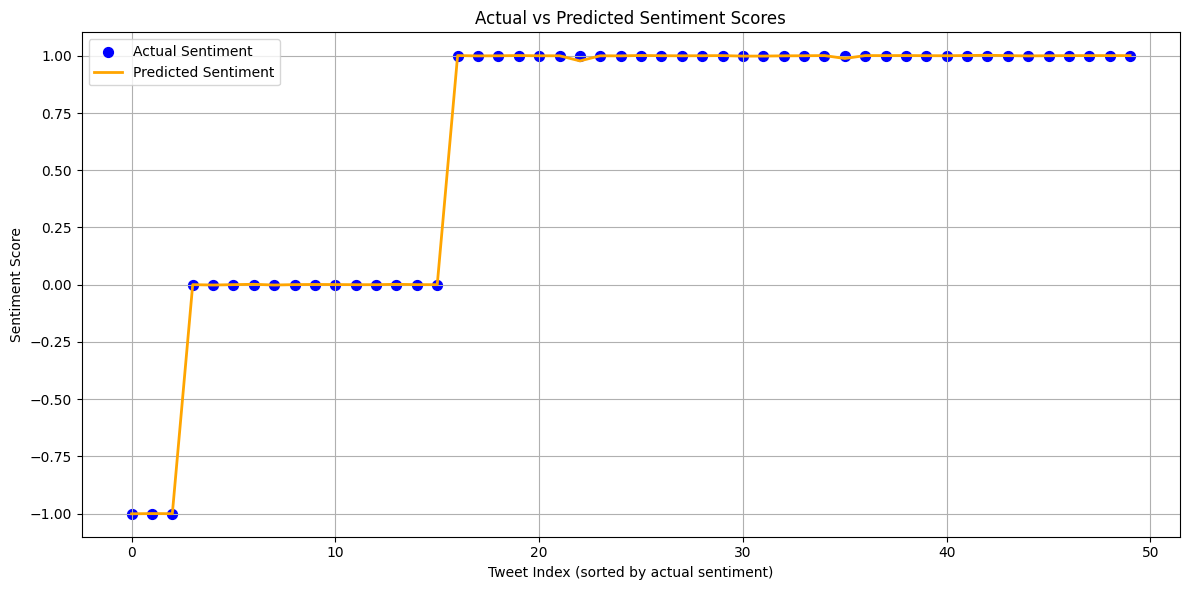

In [ ]:
plt.figure(figsize=(12,6))

# Scatter for discrete actual sentiment
plt.scatter(
    test_df_sorted.index,
    test_df_sorted['actual_sentiment'],
    label='Actual Sentiment',
    color='blue',
    marker='o',
    s=50
)

# Line plot for continuous predicted sentiment
plt.plot(
    test_df_sorted.index,
    test_df_sorted['predicted_sentiment'],
    label='Predicted Sentiment',
    color='orange',
    linewidth=2
)

plt.title('Actual vs Predicted Sentiment Scores')
plt.xlabel('Tweet Index (sorted by actual sentiment)')
plt.ylabel('Sentiment Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
#  Aggregate by candidate to find predicted winner ---
candidate_scores = test_df.groupby('candidate')['predicted_sentiment'].mean()

In [ ]:
# Candidate with highest average predicted sentiment
winner = candidate_scores.idxmax()
winning_score = candidate_scores.max()

print("\n🗳️ Average predicted sentiment per candidate:\n")
print(candidate_scores.sort_values(ascending=False))

print(f"\n🏆 Predicted winner: {winner} (Avg sentiment: {winning_score:.2f})")


🗳️ Average predicted sentiment per candidate:

candidate
Kamala Harris     1.000904
Chase Oliver      1.000559
Jill Stein        0.999116
Donald Trump      0.098257
Robert Kennedy   -0.000155
Name: predicted_sentiment, dtype: float32

🏆 Predicted winner: Kamala Harris (Avg sentiment: 1.00)
